In [1]:
from collections import defaultdict
from pathlib import Path

import pandas as pd

from decent_bench.benchmark import MetricResult, display_metrics
from decent_bench.metrics import ComputationalCost
from decent_bench.utils.checkpoint_manager import CheckpointManager
from decent_bench.utils.logger import start_logger

In [2]:
metrics = {"accuracy", "loss", "consensus error", "nr gradient calls"}
start_logger()

In [3]:
network_config = Path(r"results/heterogeneous/5_4/test_None_True_None_None")

In [9]:
use_z_mask_score = True
table_data = []
plot_data = MetricResult(None, None, None, None, None)
for checkpoint_dir in network_config.iterdir():
    # for checkpoint_dir in Path(
    #     "/home/ubuntu/github/decent-bench/examples/nim/results/heterogeneous/5_4/test_None_True_None_None"
    # ).iterdir():
    if not checkpoint_dir.is_dir():
        display(f"Skipping {checkpoint_dir} since it is not a directory")
        continue

    drops, activity, compression, noise = checkpoint_dir.parent.name.split("_")[1:]

    if compression == "True" or noise == "True":
        display(f"Skipping {checkpoint_dir} since it is a compression or noise checkpoint")
        continue

    if use_z_mask_score and activity == "True" and checkpoint_dir.name.startswith("LT-ADMM"):
        if checkpoint_dir.name == "LT-ADMM":
            # Replace results/heterogeneous/5_4/test_True_True_True_True/LT-ADMM
            # with results/no_mask_z/heterogeneous/5_4/test_True_True_True_True
            new_path = (
                checkpoint_dir.parent.parent.parent.parent
                / "no_mask_z"
                / checkpoint_dir.parent.parent.parent.name
                / checkpoint_dir.parent.parent.name
                / checkpoint_dir.parent.name
            )
            display("Updated path for z masking")
            checkpoint_manager = CheckpointManager(new_path)
        else:
            display(f"Skipping {checkpoint_dir} since it is an activity checkpoint")
            continue
    else:
        checkpoint_manager = CheckpointManager(checkpoint_dir)
    try:
        metrics_result = checkpoint_manager.load_metrics_result(skip_agent_metrics=False)
    except Exception as e:
        display(f"Error loading metrics result for {checkpoint_dir}: {e}")
        continue
    for alg, table in metrics_result.table_results.items():
        alg_data = {"algorithm": alg.name}  # + "-" + checkpoint_dir.name.replace("mnist", "")}
        for metric, values in table.items():
            if metric.table_description not in metrics:
                continue
            for statistic, value in values.items():
                if statistic != "avg":
                    continue
                alg_data[metric.table_description] = value[0]
                alg_data[metric.table_description + "_std"] = value[1]
        table_data.append(alg_data)

    if plot_data.plot_results is None:
        plot_data.plot_results = metrics_result.plot_results
    else:
        plot_data.plot_results.update(metrics_result.plot_results)

    if plot_data.agent_metrics is None:
        plot_data.agent_metrics = metrics_result.agent_metrics
    else:
        plot_data.agent_metrics.update(metrics_result.agent_metrics)

    if plot_data.plot_metrics is None:
        plot_data.plot_metrics = (
            metrics_result.plot_metrics
            if not isinstance(metrics_result.plot_metrics, list)
            else [m for mm in metrics_result.plot_metrics for m in mm]
        )

df = pd.DataFrame(table_data).sort_values("accuracy", ascending=False)

'Skipping results/heterogeneous/5_4/test_None_True_None_None/LT-ADMM-TORCH since it is an activity checkpoint'

[04/07/26 21:00:38] INFO     Loaded computed metrics result from                          ]8;id=122930;file:///home/ubuntu/github/decent-bench/decent_bench/utils/checkpoint_manager.py\checkpoint_manager.py]8;;\:]8;id=430461;file:///home/ubuntu/github/decent-bench/decent_bench/utils/checkpoint_manager.py#677\677]8;;\
                             results/heterogeneous/5_4/test_None_True_None_None/ProxSkip/                          
                             metric_computation.pkl.zst                                                            

'Updated path for z masking'

[04/07/26 21:01:31] INFO     Loaded computed metrics result from                          ]8;id=186349;file:///home/ubuntu/github/decent-bench/decent_bench/utils/checkpoint_manager.py\checkpoint_manager.py]8;;\:]8;id=676609;file:///home/ubuntu/github/decent-bench/decent_bench/utils/checkpoint_manager.py#677\677]8;;\
                             results/no_mask_z/heterogeneous/5_4/test_None_True_None_None                          
                             /metric_computation.pkl.zst                                                           

[04/07/26 21:01:37] INFO     Loaded computed metrics result from                          ]8;id=298767;file:///home/ubuntu/github/decent-bench/decent_bench/utils/checkpoint_manager.py\checkpoint_manager.py]8;;\:]8;id=68865;file:///home/ubuntu/github/decent-bench/decent_bench/utils/checkpoint_manager.py#677\677]8;;\
                             results/heterogeneous/5_4/test_None_True_None_None/DGD/metri                          
                             c_computation.pkl.zst                                                                 

'Skipping results/heterogeneous/5_4/test_None_True_None_None/LT-ADMM-EMA-TORCH since it is an activity checkpoint'

'Skipping results/heterogeneous/5_4/test_None_True_None_None/LT-ADMM-VR since it is an activity checkpoint'

'Skipping results/heterogeneous/5_4/test_None_True_None_None/LT-ADMM-EMA since it is an activity checkpoint'

[04/07/26 21:01:50] INFO     Loaded computed metrics result from                          ]8;id=782325;file:///home/ubuntu/github/decent-bench/decent_bench/utils/checkpoint_manager.py\checkpoint_manager.py]8;;\:]8;id=918712;file:///home/ubuntu/github/decent-bench/decent_bench/utils/checkpoint_manager.py#677\677]8;;\
                             results/heterogeneous/5_4/test_None_True_None_None/LED/metri                          
                             c_computation.pkl.zst                                                                 

[04/07/26 21:02:01] INFO     Loaded computed metrics result from                          ]8;id=570731;file:///home/ubuntu/github/decent-bench/decent_bench/utils/checkpoint_manager.py\checkpoint_manager.py]8;;\:]8;id=693362;file:///home/ubuntu/github/decent-bench/decent_bench/utils/checkpoint_manager.py#677\677]8;;\
                             results/heterogeneous/5_4/test_None_True_None_None/KGT/metri                          
                             c_computation.pkl.zst                                                                 

In [10]:
# Update metrics object to be the same and filter out algorithms
new_plot_values = {}
new_agent_metrics = {}
for alg, values in plot_data.plot_results.items():
    if "TORCH" in alg.name:
        display(f"Skipping {alg.name} since it is a TORCH algorithm")
        continue

    name_split = alg.name.split(" ")
    if len(name_split) > 1:
        match_name = name_split[0] + " "
    else:
        match_name = alg.name
    alg_res = df[df["algorithm"].str.match(match_name)]
    if len(alg_res) == 0:
        display(f"Could not find results for algorithm {alg.name} in dataframe, skipping")
        continue

    best_alg_name = alg_res.iloc[0]["algorithm"]
    if best_alg_name != alg.name:
        display(f"Algorithm name {alg.name} does not match best algorithm name {best_alg_name}, skipping")
        continue

    agent_metrics = plot_data.agent_metrics[alg] if plot_data.agent_metrics is not None else None
    if "ss" in alg.name:
        # Remove ", ss: XXX" from name
        display(f"Original algorithm name: {alg.name}")
        alg.name = alg.name.split(", ss")[0]
        alg.name += ")"
        display(f"Updated algorithm name: {alg.name}")

    new_plot_values[alg] = {}
    for metric, data in values.items():
        plot_metric_obj = [m for m in plot_data.plot_metrics if m.plot_description == metric.plot_description][0]
        new_plot_values[alg][plot_metric_obj] = data

    if plot_data.agent_metrics is not None:
        new_agent_metrics[alg] = agent_metrics
old_plot_values = plot_data.plot_results
old_agent_metrics = plot_data.agent_metrics
plot_data.plot_results = new_plot_values
plot_data.agent_metrics = new_agent_metrics
plot_data.plot_results = dict(sorted(plot_data.plot_results.items(), key=lambda x: x[0].name))

'Algorithm name ProxSkip (p=0.20) does not match best algorithm name ProxSkip (p=0.10), skipping'

'Algorithm name LT-ADMM (ls=5) does not match best algorithm name LT-ADMM (ls=10), skipping'

'Algorithm name LT-ADMM-EMA (ls=5) does not match best algorithm name LT-ADMM-EMA (ls=10), skipping'

'Skipping LT-ADMM-EMA-TORCH (ls=10) since it is a TORCH algorithm'

'Skipping LT-ADMM-EMA-TORCH (ls=5) since it is a TORCH algorithm'

'Skipping LT-ADMM-TORCH (ls=10) since it is a TORCH algorithm'

'Skipping LT-ADMM-TORCH (ls=5) since it is a TORCH algorithm'

'Algorithm name LT-ADMM-VR (ls=5) does not match best algorithm name LT-ADMM-VR (ls=10), skipping'

'Algorithm name LED (ls=5) does not match best algorithm name LED (ls=10), skipping'

'Algorithm name KGT (ls=5) does not match best algorithm name KGT (ls=10), skipping'

In [6]:
df

,algorithm,consensus error,consensus error_std,nr gradient calls,nr gradient calls_std,accuracy,accuracy_std,loss,loss_std
13,"LT-ADMM-EMA (ls=10, ss=0.005)",0.012743,0.014031,255786.666667,2272.611771,0.876613,0.003958,0.363190,0.039252
14,"LT-ADMM-EMA (ls=10, ss=0.01)",0.100062,0.102919,256768.000000,967.066867,0.861949,0.037265,0.244241,0.119802
4,LT-ADMM (ls=10),0.201864,0.145078,255786.666667,2272.611771,0.859758,0.077446,0.253993,0.153956
7,"LT-ADMM-EMA-TORCH (ls=10, ss=0.0005)",0.066105,0.044354,255786.666667,2272.611771,0.827983,0.044233,0.420761,0.066600
16,"LT-ADMM-EMA (ls=5, ss=0.01)",0.173988,0.026808,128032.000000,1533.194018,0.808011,0.085910,0.321319,0.081045
10,"LT-ADMM-EMA-TORCH (ls=5, ss=0.001)",0.343554,0.058858,128032.000000,1533.194018,0.795240,0.103770,0.352311,0.144104
9,"LT-ADMM-EMA-TORCH (ls=5, ss=0.0005)",0.107916,0.161281,126240.000000,3182.675840,0.792956,0.075745,0.620128,0.243067
15,"LT-ADMM-EMA (ls=5, ss=0.005)",0.018586,0.014588,126240.000000,3182.675840,0.786204,0.010826,0.649500,0.085162
8,"LT-ADMM-EMA-TORCH (ls=10, ss=0.001)",0.203809,0.085206,256768.000000,967.066867,0.784916,0.108410,0.204466,0.196096
0,LT-ADMM-TORCH (ls=10),0.444025,0.457317,255786.666667,2272.611771,0.765044,0.113259,0.633161,0.526050


[04/07/26 20:59:16] WARNING  No table metrics to display.                                             ]8;id=602494;file:///home/ubuntu/github/decent-bench/decent_bench/metrics/_tables.py\_tables.py]8;;\:]8;id=709016;file:///home/ubuntu/github/decent-bench/decent_bench/metrics/_tables.py#55\55]8;;\

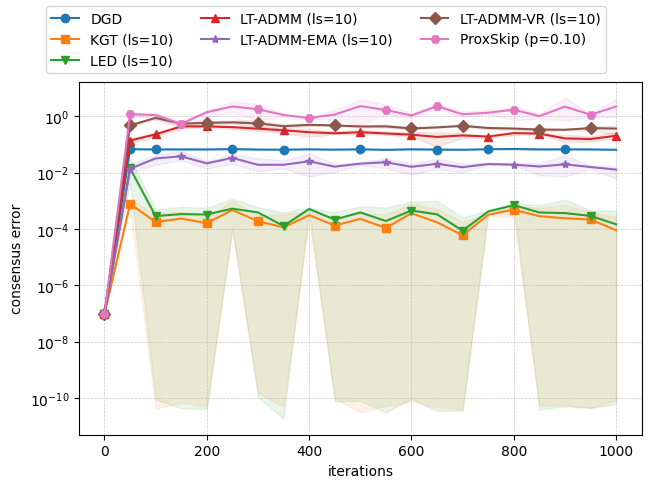

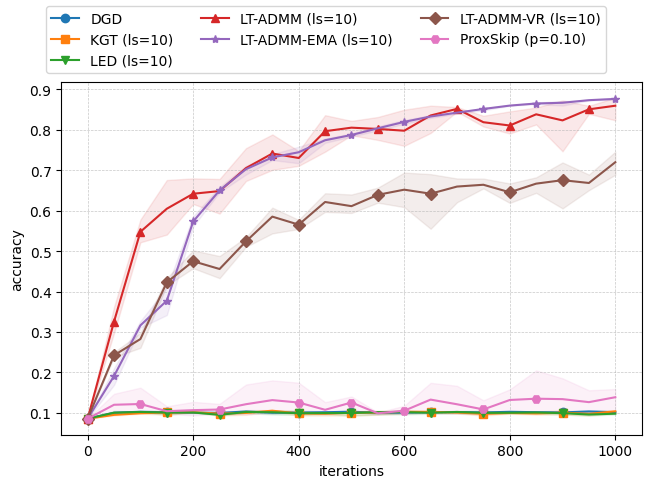

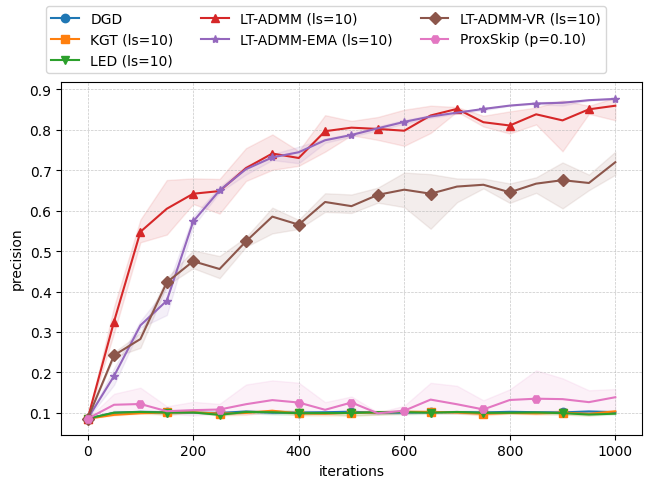

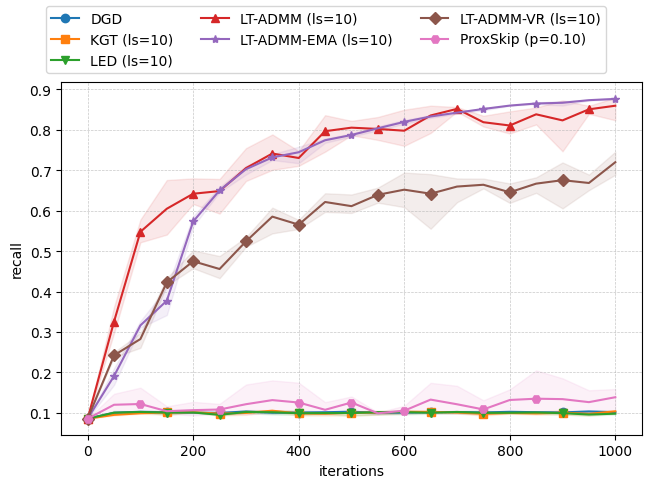

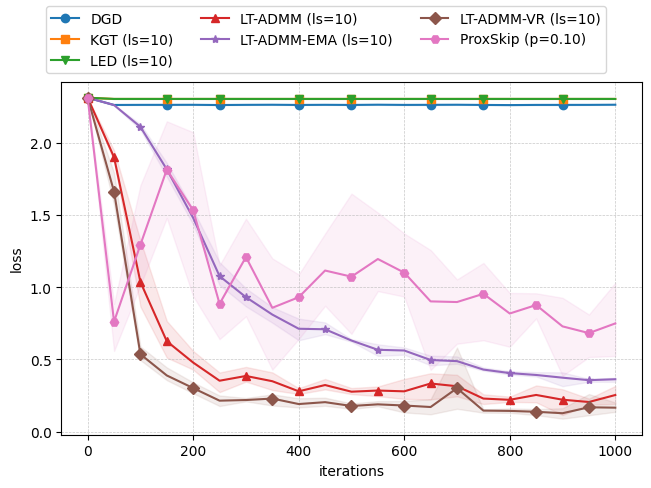

In [8]:
display_metrics(plot_data, individual_plots=True)